# Model Building

## Objective

Build and evaluate machine learning models to predict student placement outcomes using academic performance, skills, internships, certifications, and project experience.

## Data Preparation

### Train-Test Split

The dataset was divided into training and testing sets using an 80-20 split.

* Training Set: 36,000 records
* Testing Set: 9,000 records

### Feature Scaling

Feature scaling was performed using StandardScaler after the train-test split to prevent data leakage.

* Training data: fit_transform()
* Testing data: transform()

This ensured that all features were on a comparable scale, improving model performance and convergence.

## Models Evaluated

| Model               | Accuracy |
| ------------------- | -------: |
| Logistic Regression |   86.47% |
| Decision Tree       |  100.00% |
| Random Forest       |  100.00% |

### Key Findings

* Logistic Regression served as the baseline model and achieved 86.47% accuracy.
* Decision Tree achieved perfect classification with 100% accuracy.
* Random Forest also achieved 100% accuracy.
* Tree-based models significantly outperformed Logistic Regression on this dataset.

## Logistic Regression

### Model Overview

Logistic Regression was selected as the baseline classification model.

### Results

- Accuracy: **86.47%**
- F1-score (Not Placed): **0.89**
- F1-score (Placed): **0.81**
- Recall (Placed): **81%**
- Precision (Placed): **82%**

### Confusion Matrix

| Actual / Predicted | Not Placed | Placed |
|-------------------|------------|---------|
| Not Placed | 5131 | 578 |
| Placed | 640 | 2651 |

### Summary

Logistic Regression achieved an accuracy of 86.47% on unseen test data and serves as a strong baseline model for comparison with Decision Tree and Random Forest.

In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [ ]:
X = pd.read_csv("../data/X_processed.csv")
y = pd.read_csv("../data/y_processed.csv")

In [ ]:
y.head()

,Placement_Status
0,Not Placed
1,Not Placed
2,Not Placed
3,Placed
4,Placed


In [ ]:
y["Placement_Status"] = y["Placement_Status"].map({"Not Placed" : 0, "Placed" : 1})

In [ ]:
y["Placement_Status"].unique()

array([0, 1])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y["Placement_Status"], test_size=0.2, random_state=42)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(36000, 20)
(9000, 20)
(36000,)
(9000,)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled.shape

(36000, 20)

In [ ]:
model = LogisticRegression()
model.fit(X_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [ ]:
import joblib

joblib.dump(model, "../models/logistic_regression.joblib")
joblib.dump(scaler, "../models/scaler.joblib")

['../models/scaler.joblib']

In [ ]:
y_pred = model.predict(X_test_scaled)

In [ ]:
y_pred[:10]

array([1, 0, 1, 1, 0, 0, 1, 1, 1, 0])

In [ ]:
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy : ", accuracy)

Accuracy :  0.8646666666666667


In [ ]:
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[5131  578]
 [ 640 2651]]


In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.89      0.90      0.89      5709
           1       0.82      0.81      0.81      3291

    accuracy                           0.86      9000
   macro avg       0.86      0.85      0.85      9000
weighted avg       0.86      0.86      0.86      9000



## Decision Tree

### Results

- Accuracy: **100.00%**
- Tree Depth: **6**
- Leaf Nodes: **12**

### Confusion Matrix

| Actual / Predicted | Not Placed | Placed |
|-------------------|------------|---------|
| Not Placed | 5709 | 0 |
| Placed | 0 | 3291 |

### Summary

Decision Tree achieved perfect classification on the test dataset with 100% accuracy. The model required only 6 levels and 12 leaf nodes, indicating that the dataset follows a clear decision structure.

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [ ]:
y_pred_dt = dt_model.predict(X_test)

In [ ]:
accuracy_dt = accuracy_score(y_test,y_pred_dt)
print("Accuracy of DT: ", accuracy_dt)

Accuracy of DT:  1.0


In [ ]:
X.columns.tolist()

['Age',
 'Gender',
 'CGPA',
 'Internships',
 'Projects',
 'Coding_Skills',
 'Communication_Skills',
 'Aptitude_Test_Score',
 'Soft_Skills_Rating',
 'Certifications',
 'Backlogs',
 'Degree_B.Sc',
 'Degree_B.Tech',
 'Degree_BCA',
 'Degree_MCA',
 'Branch_CSE',
 'Branch_Civil',
 'Branch_ECE',
 'Branch_IT',
 'Branch_ME']

In [48]:
print("Depth:", dt_model.get_depth())
print("Leaves:", dt_model.get_n_leaves())

Depth: 6
Leaves: 12


In [49]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
print(cm_dt)

[[5709    0]
 [   0 3291]]


## Random Forest

### Results

- Accuracy: **100.00%**

### Summary

Random Forest achieved 100% accuracy on the test dataset. The ensemble model perfectly classified all test instances, matching the performance of the Decision Tree model.

In [50]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [51]:
y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test,y_pred_rf)
print("Accuracy RF: ", accuracy_rf)

Accuracy RF:  1.0


## Cross Validation

To verify model generalization I did a 5-fold cross-validation on the Decision Tree model.

### Results

- CV scores:  [1. 1. 1. 1. 1.]
- Mean CV accuracy:  1.0

### Conclusion

The model achieved perfect performance across all folds indicating consistent generalization on the dataset. The dataset follows a highly separable decision structure.

In [52]:
dt_cv_scores = cross_val_score(dt_model, X, y, cv=5, scoring="accuracy")
print("CV scores: ", dt_cv_scores)
print("Mean CV accuracy: ", dt_cv_scores.mean())



CV scores:  [1. 1. 1. 1. 1.]
Mean CV accuracy:  1.0


## Feature importance

The most influential features:

1. Communication Skills
2. Backlogs
3. CGPA
4. Coding Skills
5. Projects

The importance scores were distributed across multiple features, indicating that the model was not relying on a single dominant variable. No evidence of direct target leakage was observed.

In [53]:
feature_importances = pd.DataFrame(
    {"Feature": X.columns, "Importance": rf_model.feature_importances_}
)

feature_importances.sort_values(by="Importance", ascending=False)

,Feature,Importance
6,Communication_Skills,0.309880
10,Backlogs,0.184107
2,CGPA,0.153488
5,Coding_Skills,0.102520
4,Projects,0.087880
9,Certifications,0.074722
7,Aptitude_Test_Score,0.064900
3,Internships,0.010438
0,Age,0.002724
8,Soft_Skills_Rating,0.002587


## Plotting Decision Tree

Decision tree visualization was performed to know why the accuracy was perfect behind tree based models.

The strong features were Communication Skills, Backlogs, CGPA, Coding Skills, and Projects. Decision tree visualization showed that placement predictions were mainly determined through a small number of decision rules based on these features.

The model achieved 100% accuracy on both the test set and 5-fold cross-validation. This suggests that the dataset follows a highly separable rule based structure and is synthetic rather than representative of real-world placement data. :/

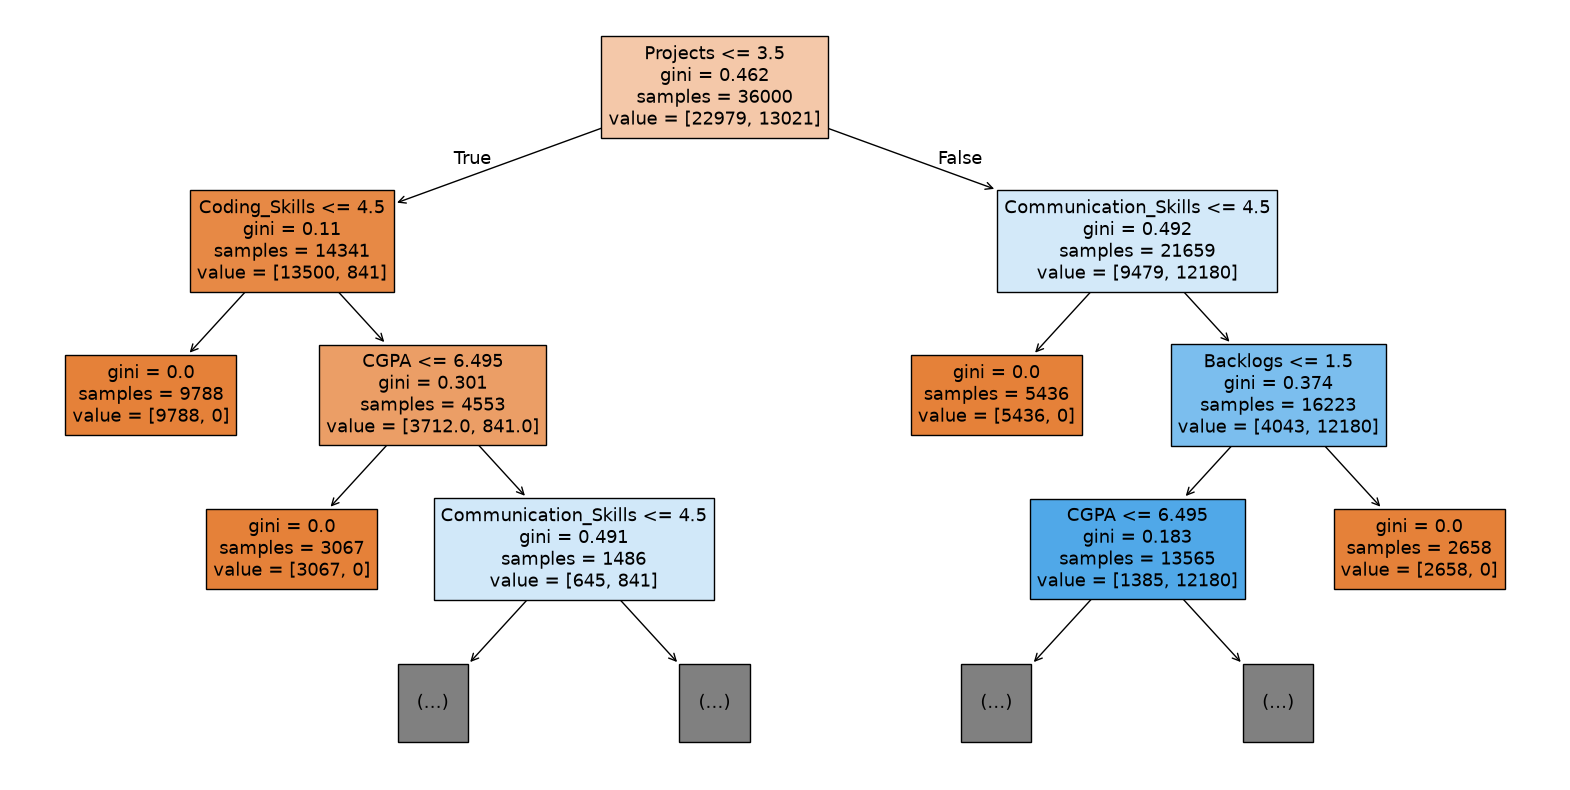

In [54]:
plt.figure(figsize=(20, 10))

plot_tree(dt_model, feature_names=X.columns, filled=True, max_depth=3)

plt.show()

In [55]:
loaded_model = joblib.load("../models/logistic_regression.joblib")
loaded_scaler = joblib.load("../models/scaler.joblib")

In [56]:
loaded_model.predict(X_test_scaled[:5])

array([1, 0, 1, 1, 0])

In [57]:
X.columns.tolist()

['Age',
 'Gender',
 'CGPA',
 'Internships',
 'Projects',
 'Coding_Skills',
 'Communication_Skills',
 'Aptitude_Test_Score',
 'Soft_Skills_Rating',
 'Certifications',
 'Backlogs',
 'Degree_B.Sc',
 'Degree_B.Tech',
 'Degree_BCA',
 'Degree_MCA',
 'Branch_CSE',
 'Branch_Civil',
 'Branch_ECE',
 'Branch_IT',
 'Branch_ME']

In [58]:
with open("../features.txt", "w") as f:
    for col in X.columns:
        f.write(col + "\n")